# Is the Schaff Trend Cycle really a "faster MACD"? 📉
### A popular oscillator that promises to turn earlier — and what happens when you actually trade it

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Faster_MACD%3F: Busted](https://img.shields.io/badge/Faster_MACD%3F-Busted-8b949e?style=flat-square)

The **Schaff Trend Cycle** (STC) is a chart indicator with a great pitch: it's a *"faster MACD"*. Doug Schaff built it in 2008 by running a couple of extra math tricks on top of the classic MACD so the line **whips up and down more quickly** — the idea being you catch trends *earlier* and make more money than the laggy old MACD.

It's all over TradingView and YouTube. So we did the obvious thing: turned the STC into a simple **buy/sell timing rule** on the S&P 500, and asked two blunt questions — *does it beat just buying and holding?* and *does it beat the plain MACD it claims to improve on?*

> 📓 **Plain-language layer.** Want the *t*-stats, the permutation test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from schaff_trend_cycle import data, strategy as st

HAVE_REAL = data.have_real("SPY")
SPY = data.load_real("SPY") if HAVE_REAL else None
print("real SPY cache present:", HAVE_REAL, "| bars:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '1993-01-29', 'end': '2026-05-29', 'years': 33.3, 'n_days': 8390, 'fp': '0207fbae81b3', 'stc_sharpe': 0.29, 'bh_sharpe': 0.65, 'macd_sharpe': 0.42, 'stc_minus_bh': -0.36, 'stc_cagr': 0.029, 'bh_cagr': 0.109, 'stc_maxdd': -0.5, 'bh_maxdd': -0.55, 'stc_hac_t': 1.87, 'turnover': 17.4, 'exposure': 0.54, 'perm_p': 0.96, 'ls_stc_sharpe': -0.26, 'ls_macd_sharpe': -0.16, 'ls_hac_t': -1.75, 'ls_cagr': -0.064, 'ls_maxdd': -0.91, 'cost': [(0.0, 0.31, 1.96), (1.0, 0.29, 1.87), (2.0, 0.28, 1.78), (5.0, 0.24, 1.51), (10.0, 0.17, 1.07)], 'panel': [('SPY', 8390, 0.29, 0.65, 0.42, 1.87), ('QQQ', 6848, 0.2, 0.52, 0.21, 1.07), ('IWM', 6540, 0.36, 0.47, 0.42, 2.0), ('EFA', 6225, 0.26, 0.41, 0.19, 1.45), ('AAPL', 11457, 0.37, 0.63, 0.61, 2.36), ('MSFT', 10131, 0.43, 0.84, 0.57, 2.7)], 'syn': [(0.0, -0.35, -0.16, -0.19, -1.42), (0.003, 0.82, 0.72, 0.1, 2.66)]}


real SPY cache present: True | bars: 8390


## The answer first

| Question | Answer |
|---|---|
| Does the STC rule beat **buy-and-hold** on the S&P 500? | **No.** Net Sharpe **0.29** vs buy-and-hold's **0.65** — it gives up about half the risk-adjusted return, and grows your money at **2.9%/yr** vs **10.9%/yr**. |
| Is the edge even **real** (not luck)? | **No.** The HAC *t* is **1.87** (below the 2.0 bar), and a shuffled-position placebo beats it **96%** of the time. |
| Does it beat the **plain MACD** it claims to improve on? | **No.** STC Sharpe **0.29** vs a vanilla MACD crossover's **0.42** — the "faster" version is actually **worse** than the thing it's faster than. |
| Does shorting (long/short) help? | **No — it's worse.** The long/short version loses money outright (Sharpe **-0.26**, a **91%** drawdown). |

> The promise is "turn faster, profit more." The tape says: turning faster just means **more whipsaws, more costs, and less money** than doing nothing.

## 1 · The claim

> *"The MACD is good but **slow** — it lags the turn. The Schaff Trend Cycle fixes that: it cycles between 0 and 100 and snaps to the new trend **much sooner**, so you get in and out earlier and beat both the MACD and a passive buy-and-hold."*

This is the standard pitch from the indicator's fans. It's a *steelman* worth testing because it's specific: there's a clear rule (long when STC rises through 25, exit when it falls through 75) and a clear benchmark (the MACD). If "faster = better" is true, the STC rule should out-earn both. Let's see.

## 2 · So what?

If a simple oscillator on a daily chart could reliably beat buy-and-hold on the **S&P 500** — the single most-studied, most-efficient market on earth — that would be a small miracle. It would mean the index's future direction is predictable from a squiggly line anyone can compute for free. Whole hedge funds would be out of a job.

The honest prior is that it **won't**, because the same trap catches almost every chart indicator: a trend rule that flips direction on a moving line *lags* the actual turn, eats trading costs on every flip, and sits in cash through chunks of the relentless upward drift that buy-and-hold simply collects. "Faster" makes that *worse*, not better, in a choppy market — more flips, more whipsaw.

## 3 · How would we know?

- **The tape.** The S&P 500 (SPY), daily, total-return adjusted, **1993-01-29 → 2026-05-29** (~33 years, 8,390 bars).
- **The rule.** Compute the STC. Go **long** when it crosses **up through 25**; go **flat** when it crosses **down through 75**. Hold between signals.
- **No cheating.** The signal is known at today's close; we earn **tomorrow's** return (one day's delay). We charge a realistic trading cost on every flip.
- **The fair race.** Compare its **risk-adjusted** return (Sharpe) to buy-and-hold *and* to a plain MACD crossover — because "it makes money" is meaningless if buying and holding makes *more*.
- **The mirage test.** If the STC rule's Sharpe is **below** buy-and-hold, or its edge can't clear a *t* of 2 and beat a shuffled-position placebo — we call it a mirage.

## 4 · The teardown — let's actually look

**First, the money.** Here are the equity curves: a dollar in the STC timing rule vs a dollar just buying and holding the S&P. Same tape, same costs, one-day execution lag.

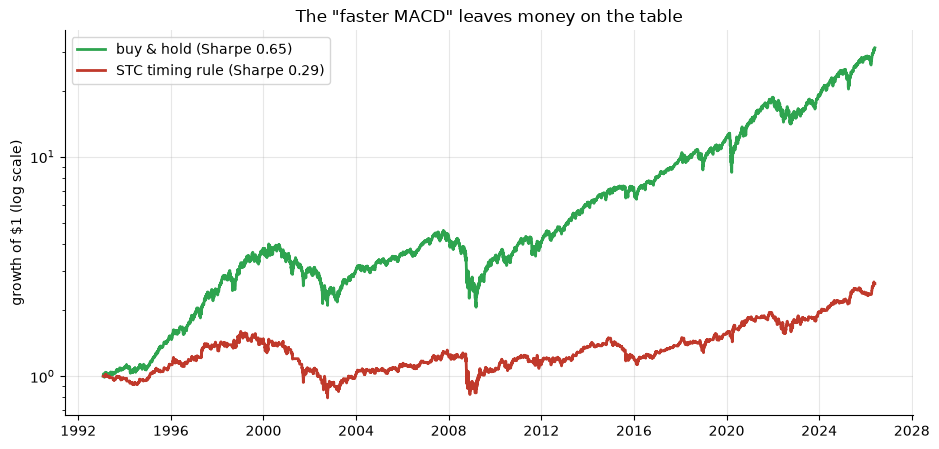

STC CAGR 2.9%/yr  vs  buy-and-hold 10.9%/yr


In [2]:
if HAVE_REAL:
    stc = st.schaff_trend_cycle(SPY['close'])
    pos = st.stc_positions(stc)
    bk = st.book_returns(SPY, pos, cost_bps=1.0)
    eq_stc = (1+bk['strat_excess']).cumprod()
    eq_bh  = (1+bk['ret']).cumprod()
    idx = SPY.index
else:
    idx = None
fig, ax = plt.subplots(figsize=(9.5, 4.6))
if HAVE_REAL:
    ax.semilogy(idx, eq_bh, color=GREEN, lw=2, label=f"buy & hold (Sharpe {R['bh_sharpe']:.2f})")
    ax.semilogy(idx, eq_stc, color=RED, lw=2, label=f"STC timing rule (Sharpe {R['stc_sharpe']:.2f})")
ax.set_ylabel('growth of $1 (log scale)'); ax.set_title('The "faster MACD" leaves money on the table')
ax.legend(); plt.tight_layout(); plt.show()
print(f"STC CAGR {R['stc_cagr']*100:.1f}%/yr  vs  buy-and-hold {R['bh_cagr']*100:.1f}%/yr")

The red line (STC) ends **far below** the green line (buy-and-hold). It grows your money at **2.9%/yr** against buy-and-hold's **10.9%/yr** — and it doesn't even buy you a much smoother ride (the worst drawdowns are similar). Sitting in cash through half the bull market is expensive.

**Now the head-to-head it actually cares about: does "faster" beat the plain MACD?** Here's the risk-adjusted return (Sharpe) of the STC rule, the vanilla MACD crossover, and buy-and-hold.

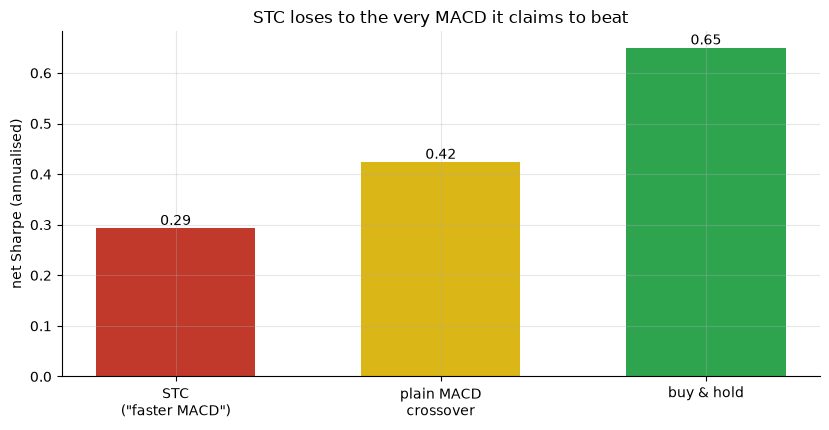

STC 0.29  <  MACD 0.42  <  buy-and-hold 0.65


In [3]:
if HAVE_REAL:
    r = st.run_experiment(SPY, cost_bps=1.0)
    vals = [r['stc_sharpe'], r['macd_sharpe'], r['bh_sharpe']]
else:
    vals = [R['stc_sharpe'], R['macd_sharpe'], R['bh_sharpe']]
labels = ['STC\n("faster MACD")', 'plain MACD\ncrossover', 'buy & hold']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labels, vals, color=[RED, AMBER, GREEN], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('net Sharpe (annualised)'); ax.set_title('STC loses to the very MACD it claims to beat')
plt.tight_layout(); plt.show()
print(f"STC {vals[0]:.2f}  <  MACD {vals[1]:.2f}  <  buy-and-hold {vals[2]:.2f}")

There's the punchline. The STC rule's Sharpe (**0.29**) is **below** the plain MACD's (**0.42**), which is itself below buy-and-hold (**0.65**). The "faster MACD" is **worse than the MACD**. Speed bought whipsaws, not profit.

## 5 · The verdict

- **Signal — None.** The STC rule's edge can't clear the bar: HAC *t* = **1.87** (under 2.0), and a shuffled-position placebo beats it **96%** of the time. Indistinguishable from luck.
- **Tradability — Mirage.** Net Sharpe **0.29** vs buy-and-hold **0.65** — it *destroys* value versus doing nothing. The long/short version loses money outright.
- **"Faster MACD"? — Busted.** It doesn't beat the MACD; it underperforms it on the S&P 500 and on 5 of 6 instruments we tried. The whole selling point fails.

## 6 · Could you actually trade it?

Not for profit — it loses to the free alternative (buy-and-hold) before you even get fancy. And the costs only make it worse: the rule flips ~17 times a year, and every flip pays the spread. Here's what happens to its Sharpe as trading costs rise.

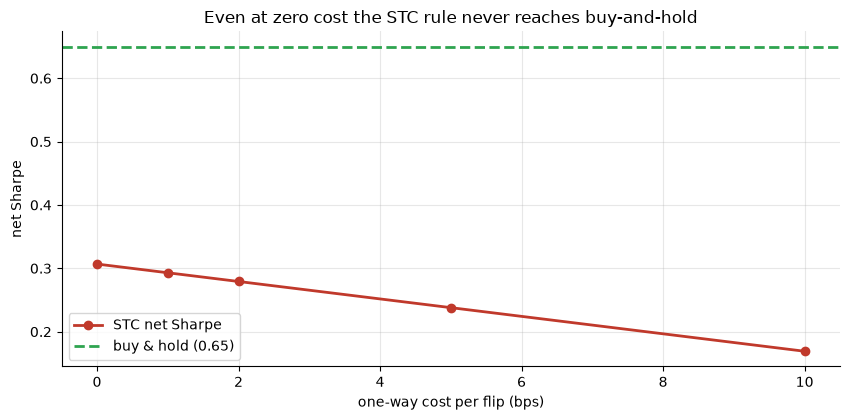

at 0 bps STC Sharpe 0.31 -- still below buy-and-hold 0.65


In [4]:
cs = [c[0] for c in R['cost']]
if HAVE_REAL:
    sh = [st.run_experiment(SPY, cost_bps=c)['stc_sharpe'] for c in cs]
else:
    sh = [c[1] for c in R['cost']]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(cs, sh, 'o-', color=RED, lw=2, label='STC net Sharpe')
ax.axhline(R['bh_sharpe'], color=GREEN, ls='--', lw=2, label=f"buy & hold ({R['bh_sharpe']:.2f})")
ax.set_xlabel('one-way cost per flip (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Even at zero cost the STC rule never reaches buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f"at 0 bps STC Sharpe {sh[0]:.2f} -- still below buy-and-hold {R['bh_sharpe']:.2f}")

The red line never touches the green dashed line — **not even at zero cost.** Costs make a bad deal worse, but they're not the killer here; the rule is simply on the wrong side of the market's drift.

## 7 · Going further 🚪

- **It's the family, not the settings.** STC, MACD, Supertrend (study 106), CCI (178) — lagging trend oscillators on the S&P keep landing in the same place: behind buy-and-hold. Try the parameter sweep and watch the conclusion survive.
- **Where might it work?** Trend rules earn their keep in *strongly trending, mean-reverting-free* markets (some commodities, some FX). The synthetic control in the quant notebook shows the engine **can** bank an edge when a real trend is planted — the S&P just doesn't hand it one net of costs.

*Think a different threshold or cycle length flips the verdict? Fork it and show an STC Sharpe above buy-and-hold, net of costs, on a market you didn't pick after the fact.*